In [15]:
import argparse
from src.load_params import *
from src.hdf5_fcts import * 
from src.scan_fcts import *
from src.astrometry_fcts import *
from astropy.io import fits
import astropy.units as u 
from astropy.coordinates import SkyCoord
from progress.bar import Bar
import pandas as pd
import h5py 
import matplotlib.patches as mpatches
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from astropy.coordinates import SkyCoord
from IPython import embed
import datetime
from matplotlib.path import Path
import matplotlib

In [16]:
col = (3.5,3.5)
col_margins = {'top':0.98,'right':0.98,'left':.2,'bottom':.15}
wide = (7.5,3.5)
wide_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.15}
full = (7.5,6)
full_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.1}

matplotlib.rcParams.update({'font.size': 11})
matplotlib.rcParams.update({'axes.grid':True})
matplotlib.rcParams.update({'xtick.direction':'in'})
matplotlib.rcParams.update({'ytick.direction':'in'})
matplotlib.rcParams.update({'xtick.top':True})
matplotlib.rcParams.update({'ytick.right':True})
matplotlib.rcParams.update({'legend.fontsize':'small'})
matplotlib.rcParams.update({'legend.frameon':False})
matplotlib.rcParams.update({'legend.fancybox':False})
matplotlib.rcParams.update({'legend.framealpha':0.6})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})

In [17]:
P = load_params('PAR_files/params_strategy.par')

#The coordinates of the field
name=P['name_field']
c=SkyCoord.from_name(name)
ra = 0 
rafield = c.ra.value
dec = c.dec.value

#load the observer position
lat = P['latitude']

#Load the resolution. 
#if not in params, load it from the map used to generate the TOD. 
res = None #P['res']
if(res is None):
    hdr = fits.getheader(P['path']+P['file'])
    res = (hdr['CDELT1'] * u.Unit(hdr['CUNIT1'])).to(u.deg).value

acquisition_frequency = P['acquisition_frequency']  #sample per frame defined here as the acquisition rate in Hz. 
dt = 1/acquisition_frequency*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 

In [20]:
#------------------------------
#Load the previously generated scanning path and time array. 
H = h5py.File(P['output_name'], "a")
T = H['data_time']['data'][()] #LST in seconds
LST = H['data_lst']['data'][()] #LST in hour angle. 
RA_path = H['data_RA_path']['data'][()] # coordinate RA timestream
DEC_path = H['data_DEC_path']['data'][()] # coordinate Dec timestream
#--- Get read of the turnarounds in the coordinates 
scan_flag = H['data_turnaround_flags']['data'][()]
scan_path = np.asarray((RA_path, DEC_path)).T
scan_path = scan_path[scan_flag==1] #Use the scan flag to keep only the constant scan speed part of the pointing. 
T = T[scan_flag==1]
LST = LST[scan_flag==1]
#--- 
H.close()
#-----------------------------

In [21]:
#-------------------------------
#Load the sky simulation from which to generate the TODs from
simu_sky_path = P['path']+P['file'] #os.getcwd()
hdr  = fits.getheader(simu_sky_path)
pix_size = ((hdr['CDELT1']*u.Unit(hdr['CUNIT1']))**2).to(u.sr).value
hdr['CRVAL1'] = ra 
hdr['CRVAL2'] = dec
hdr['CRPIX1'] = hdr['NAXIS1']//2
hdr['CRPIX2'] = hdr['NAXIS2']//2
#Create the list of frequency channels of the simulated cube. 
if('R' in simu_sky_path): freqs = ( np.exp( hdr['CRVAL3'] + hdr['CDELT3'] * np.arange(hdr['NAXIS3']) ) *u.Unit(hdr['CUNIT3']) ).to(u.GHz)
else: freqs =( np.arange(hdr['CRVAL3'], hdr['CRVAL3']+hdr['NAXIS3']*hdr['CDELT3'], hdr['CDELT3'])*u.Unit(hdr['CUNIT3']) ).to(u.GHz)
ifreqs = np.arange(0, len(freqs))

#load the angular spectral cube. 
cube = fits.getdata(simu_sky_path)
#Remove the mean in each map, to wich we are not sensitive. 
cubemean = np.mean(cube, axis=(1,2)) 
cube -= cubemean[:, None, None]
cube =  cube[:P['nb_channels_per_array']*2,:,:] #restrict the frequency range to the number of frequency channels of the simulation of the instrument specifications
#---------------------------------

In [22]:
#-----------------------------
#Load the detectors specifications for each of the two arrays.
det_names_dict = pd.read_csv(P['detectors_name_file'], sep='\t')
LW = det_names_dict[det_names_dict['XEL'] > 0]
SW = det_names_dict[det_names_dict['XEL'] < 0]
#-----------------------------    

/home/mvancuyck/Desktop/TIM_analysis/timestream_maker/src/scan_fcts.py:595: RuntimeWarning: divide by zero encountered in divide
  noise  *= 1 / np.sqrt(t_pix)
/home/mvancuyck/Desktop/TIM_analysis/timestream_maker/src/scan_fcts.py:595: RuntimeWarning: divide by zero encountered in divide
  noise  *= 1 / np.sqrt(t_pix)


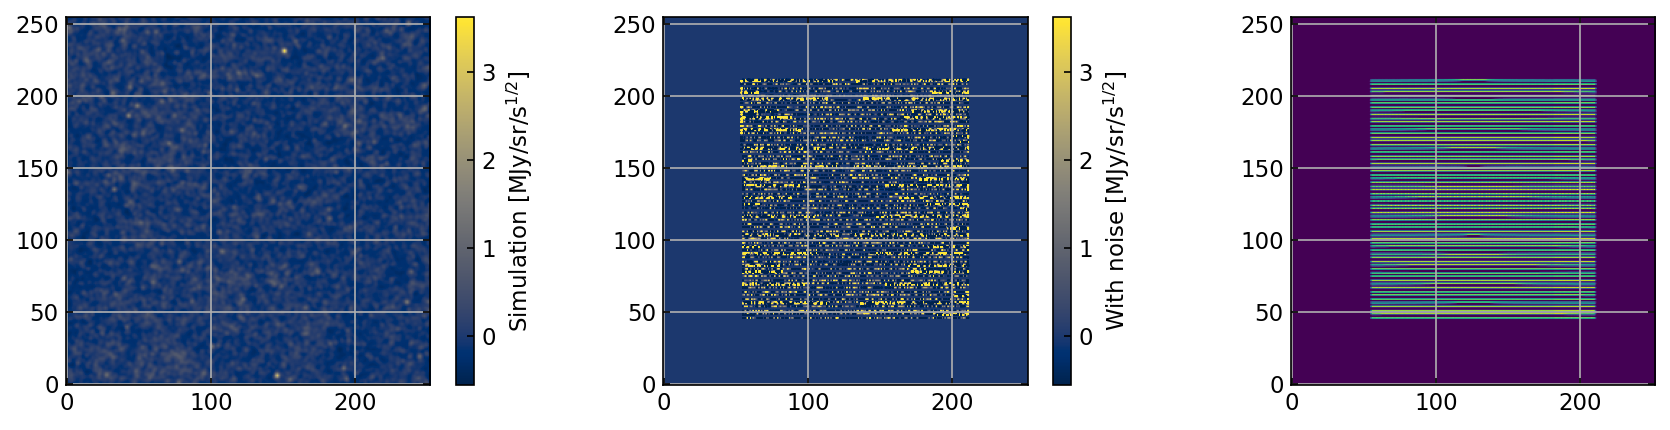

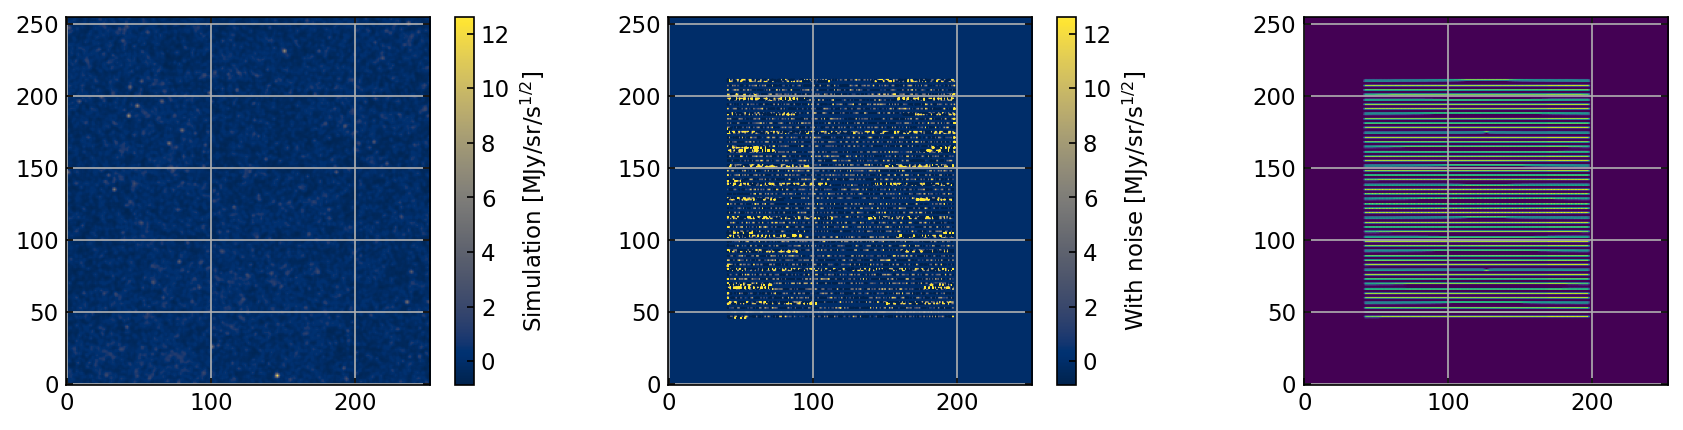

In [23]:
#---------------------------------
#Initiate some variables
cube_noisy = cube.copy()
noise_cube = np.zeros_like(cube)
hit_cube = np.zeros_like(cube)
#---------------------------------

for array_name, array, freqs_array, index_freqs in zip( ('SW', 'LW'), (SW, LW),
                                (freqs[:P['nb_channels_per_array']], 
                                freqs[ P['nb_channels_per_array']:P['nb_channels_per_array']*2 ]),
                                (ifreqs[:P['nb_channels_per_array']], 
                                ifreqs[ P['nb_channels_per_array']:P['nb_channels_per_array']*2 ])):
    #------------------------------------------------------------------
    # Group the detectors by (XEL, EL)
    same_offset_groups = array.groupby(['XEL', 'EL'])['Name'].apply(list)

    # Extract (XEL, EL) and convert to list
    xel_el_keys = same_offset_groups.index.tolist()

    # Transpose the list to a list of Names
    grouped_lists = same_offset_groups.tolist()
    transposed_groups = list(zip(*grouped_lists))  # One element from each group

    # Combined detectors per group of electromagnetic frequency
    frequency_groups = pd.DataFrame(transposed_groups, columns=pd.MultiIndex.from_tuples(xel_el_keys, names=["XEL", "EL"]))
    #------------------------------------------------------------------

    #-------------------------------    
    #Load the pointing offsets for a group of pixel seeing the same electromagnetic frequency
    group = frequency_groups.iloc[0]
    names = group.values
    # Extract XEL and EL from the MultiIndex of the row
    xel = group.index.get_level_values('XEL')
    el = group.index.get_level_values('EL')
    #-------------------------------
    
    #-------------------------------
    #Generate the pointing paths on the sky for each pixel
    pixel_offsets = pixels_rotations(el, xel, P['theta'])
    pointing_paths_to_save = [genPointingPath(T, scan_path, LST, lat, dec, offsets) for offsets in pixel_offsets]
    xedges,yedges,hit_map = binMap(pointing_paths_to_save,res=res,dec=dec,ra=ra,shape=cube.shape[1:]) 

    #---
    #If one wants to generate a nosie map for a longer integration time than one single observation: 
    hit_map *= 10# P['number_of_observations']
    #---

    #Save the hitmap for the frequency range. 
    hit_cube[index_freqs,:,:] = hit_map[None,:,:]
    #-------------------------------

    #-----------------------------------------
    #Load the NEI model for the given frequency range in MJy/sr
    _, noise = load_TIM_noise(observed_frequencies = freqs_array)
    #Generate from the NEI the noise maps. 
    noise_slice = noise_map(hit_map, noise, dt)
    #And save them. 
    noise_cube[index_freqs,:,:] = noise_slice
    #-----------------------------------------

    # Build boolean masks
    mask_zero = (hit_map == 0)   # shape (Ny, Nx)
    mask_nonzero = ~mask_zero    # inverse

    for fi, ff in enumerate(index_freqs):
        cube_noisy[ff][mask_zero] = 0
        cube_noisy[ff][mask_nonzero] += noise_slice[fi][mask_nonzero]
        if(fi==0):
            fig, axs = plt.subplots(1,3, figsize=(12,3), dpi=150)
            im = axs[0].imshow(cube[ff,:,:], origin='lower', cmap='cividis')
            vmin = cube[ff,:,:].min(); vmax=cube[ff,:,:].max()
            cbar = fig.colorbar(im, ax=axs[0], orientation='vertical',)
            cbar.set_label('Simulation [$ \\rm MJy/sr/s^{1/2}$]')  # Adjust the label if needed
            im = axs[1].imshow(cube_noisy[ff,:,:], origin='lower', cmap='cividis', vmin=vmin, vmax=vmax)
            cbar = fig.colorbar(im, ax=axs[1], orientation='vertical',)
            cbar.set_label('With noise [$ \\rm MJy/sr/s^{1/2}$]')  # Adjust the label if needed
            axs[2].imshow(hit_map, origin='lower')
            fig.tight_layout()
            

In [24]:

# Save the extragalactic cube, the noisy cube, the noise cube and the hit cube in one fits file. 
cubes = [cube, cube_noisy, noise_cube, hit_cube]
hdr["DATE"]  = (str(datetime.datetime.now()), "date of creation")
hdr_count = hdr.copy()
hdr_count["BUNIT"] = "counts"
hdr["COMMENT"] = f'dt={dt:.3f}s'
hdr_list = [hdr, hdr, hdr, hdr_count]
# Build HDU list
hdus = []
for i, (cube_i, hdr_i) in enumerate(zip(cubes, hdr_list)):
    if i == 0:
        # Primary HDU must come first
        hdu = fits.PrimaryHDU(cube_i, header=hdr_i)
    else:
        # Following cubes go as ImageHDUs
        hdu = fits.ImageHDU(cube_i, header=hdr_i, name=f"CUBE{i}")
    hdus.append(hdu)   

# Write all to one FITS file
hdul = fits.HDUList(hdus)
hdul.writeto(f'fits_and_hdf5/noisy_cubes_{P["file"][:-5]}.fits', overwrite=True)
hdul.close()
print('save '+f'fits_and_hdf5/noisy_cubes_{P["file"][:-5]}.fits')
#-----------------------------------------

#To open all the extensions with ds9:
#ds9 -multiframe -tile noisy_cubes[...].fits

save fits_and_hdf5/noisy_cubes_pySIDES_from_uchuu_tile_0_1.414deg_x_1.414deg_fir_lines_res20arcsec_dnu4.0GHz_full_de_Looze_smoothed_MJy_sr.fits
